# Question - Answer

###  Internal Working
- current_state = { question }

- START
 - → llm_qa(current_state)
    - → LLM call
    - → answer generate
    - → state update
- → END

return final_state


In [2]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

e:\Langgraph\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()
import os

In [4]:
api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(groq_api_key=api_key,model="llama-3.1-8b-instant")

In [ ]:
# Creat State 
class LLMstate(TypedDict):
    question:str
    answer:str

In [6]:
def llm_qa(state: LLMstate) -> LLMstate:
    
    # Extract The question from state
    question = state['question']

    # from Prompt
    prompt = f"Answer the following question {question}"

    # ask That question to the LLm
    answer = llm.invoke(prompt).content

    # update the answer in state
    state['answer'] = answer

    return state

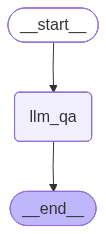

In [7]:
# create graph
graph = StateGraph(LLMstate)

# add Nodes
graph.add_node('llm_qa',llm_qa)

# add Edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# compile
workflow = graph.compile()
workflow

In [8]:
## exicute

intial_state = {'question': 'what is the networth of TATA Group Of Company'}

final_state= workflow.invoke(intial_state)
print(final_state['answer'])

The Tata Group is a multinational conglomerate with a diverse range of businesses, including automotive, steel, chemicals, energy, consumer products, and more. As of my knowledge cutoff in 2023, the estimated net worth of the Tata Group is around $420 billion (approximately ₹33.4 trillion).

However, please note that the net worth of the Tata Group can fluctuate constantly due to various market and economic factors. Here's a breakdown of the estimated net worth of some of the key Tata Group companies:

1. Tata Steel: ₹1.4 trillion (approximately $18.5 billion)
2. Tata Motors: ₹1.2 trillion (approximately $15.5 billion)
3. Tata Consultancy Services (TCS): ₹14.5 trillion (approximately $190 billion)
4. Tata Power: ₹1.3 trillion (approximately $17.5 billion)
5. Tata Chemicals: ₹1.1 trillion (approximately $14.5 billion)

The Tata Group's net worth is largely driven by the success of its technology arm, Tata Consultancy Services (TCS), which is one of the largest IT services companies in t